# Projekt – Predicting NBA Shots

Ovaj Jupyter notebook radi:
- učitavanje i inicijalni pregled `shot_logs.csv`
- detaljnu deskriptivnu statistiku (numeričke i kategorijske varijable)
- analizu nedostajućih vrijednosti i prijedloge rješenja
- osnovno čišćenje i izradu nekoliko korisnih značajki (feature engineering)
- vizualizacije koje pomažu razumjeti podatke
- treniranje modela strojnog učenja koji pokušavaju predvidjeti rezultat šuta

Članovi:
- Nikola Bačić
- Ana Gašaparov
- Filip Knapić
- Borna Lešić


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)

DATA_PATH = "shot_logs.csv"
df_raw = pd.read_csv(DATA_PATH)

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (128069, 21)


,GAME_ID,MATCHUP,LOCATION,W,FINAL_MARGIN,SHOT_NUMBER,PERIOD,GAME_CLOCK,SHOT_CLOCK,DRIBBLES,TOUCH_TIME,SHOT_DIST,PTS_TYPE,SHOT_RESULT,CLOSEST_DEFENDER,CLOSEST_DEFENDER_PLAYER_ID,CLOSE_DEF_DIST,FGM,PTS,player_name,player_id
0,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,1,1,1:09,10.8,2,1.9,7.7,2,made,"Anderson, Alan",101187,1.3,1,2,brian roberts,203148
1,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,2,1,0:14,3.4,0,0.8,28.2,3,missed,"Bogdanovic, Bojan",202711,6.1,0,0,brian roberts,203148
2,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,3,1,0:00,NaN,3,2.7,10.1,2,missed,"Bogdanovic, Bojan",202711,0.9,0,0,brian roberts,203148
3,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,4,2,11:47,10.3,2,1.9,17.2,2,missed,"Brown, Markel",203900,3.4,0,0,brian roberts,203148
4,21400899,"MAR 04, 2015 - CHA @ BKN",A,W,24,5,2,10:34,10.9,2,2.7,3.7,2,missed,"Young, Thaddeus",201152,1.1,0,0,brian roberts,203148


# Pregled, čišćenje i deskriptivna analiza podataka

## 1) Brzi pregled i provjera tipova
Provjeravamo tipove stupaca, osnovne informacije, te postoje li duplikati.

In [2]:
df = df_raw.copy()

display(df.info())
display(df.describe(include='all').T.head(30))

dup_rows = df.duplicated().sum()
print("Broj potpuno duplih redaka:", dup_rows)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   GAME_ID                     128069 non-null  int64  
 1   MATCHUP                     128069 non-null  object 
 2   LOCATION                    128069 non-null  object 
 3   W                           128069 non-null  object 
 4   FINAL_MARGIN                128069 non-null  int64  
 5   SHOT_NUMBER                 128069 non-null  int64  
 6   PERIOD                      128069 non-null  int64  
 7   GAME_CLOCK                  128069 non-null  object 
 8   SHOT_CLOCK                  122502 non-null  float64
 9   DRIBBLES                    128069 non-null  int64  
 10  TOUCH_TIME                  128069 non-null  float64
 11  SHOT_DIST                   128069 non-null  float64
 12  PTS_TYPE                    128069 non-null  int64  
 13  SHOT_RESULT   

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
GAME_ID,128069.0,NaN,NaN,NaN,21400451.878761,257.877259,21400001.0,21400233.0,21400449.0,21400673.0,21400908.0
MATCHUP,128069,1808,"FEB 07, 2015 - DAL vs. POR",105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LOCATION,128069,2,A,64135,NaN,NaN,NaN,NaN,NaN,NaN,NaN
W,128069,2,W,64595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FINAL_MARGIN,128069.0,NaN,NaN,NaN,0.208723,13.233267,-53.0,-8.0,1.0,9.0,53.0
SHOT_NUMBER,128069.0,NaN,NaN,NaN,6.506899,4.71326,1.0,3.0,5.0,9.0,38.0
PERIOD,128069.0,NaN,NaN,NaN,2.469427,1.139919,1.0,1.0,2.0,3.0,7.0
GAME_CLOCK,128069,719,0:01,859,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SHOT_CLOCK,122502.0,NaN,NaN,NaN,12.453344,5.763265,0.0,8.2,12.3,16.675,24.0
DRIBBLES,128069.0,NaN,NaN,NaN,2.023355,3.47776,0.0,0.0,1.0,2.0,32.0


Broj potpuno duplih redaka: 0


### Objasnjenje stupaca i analiza sto stupci znace

- GAME_ID - identifikator utakmice
- MATCHUP - opis utakmice, datum i tko igra
- LOCATION - home ili away, je li utakmica igrana doma ili u gostima
- W - win or loss, je li ta utakmica pobjedjena ili izgubljena
- FINAL_MARGIN - razlika u bodovima 1. i 2. ekipe
- SHOT_NUMBER - redni broj suta tog igraca na utakmici
- PERIOD - cetvrtina u kojoj je sut izveden
- GAME_CLOCK - preostalo vrijeme u toj cetvrtini
- SHOT_CLOCK - vrijeme u napadu u trenutku suta - [0,24]
- DRIBBLES - broj driblinga prije suta
- TOUCH_TIME - koliko je dugo igrac drzao loptu prije suta
- SHOT_DIST - udaljenost od kosa
- PTS_TYPE - vrijednost suta 2/3
- SHOT_RESULT - made ili missed = je li sut uspio ili nije
- CLOSEST_DEFENDER - prezime i ime najblizeg protivnickog igraca
- CLOSEST_DEFENDER_PLAYER_ID - identifikacija nablizeg protivnickog igraca
- CLOSE_DEF_DIST - udaljenst do najblizeg protivnickog igraca
- FGM - POGODJEN ILI PROMASEN SUT , 1 ili 0
- PTS - OSVOJENI bodovi, broj osvojenih bodova tim sutom (0 ako je sut promasen)
- player_name - ime i prezime igraca koji je sutirao
- player_id - id igraca koji je pucao


## 2) Nedostajuće vrijednosti
U ovom datasetu nedostaju vrijednosti samo u `SHOT_CLOCK`. Izračunajmo koliko i gdje se pojavljuju.

In [3]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)
missing_table = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_table = missing_table[missing_table["missing_count"] > 0]
missing_table

,missing_count,missing_pct
SHOT_CLOCK,5567,4.347


### 2.1) Gdje se najčešće pojavljuje `SHOT_CLOCK = NaN`?


In [4]:
miss_by_period = df.assign(miss_sc=df["SHOT_CLOCK"].isna()).groupby("PERIOD")["miss_sc"].mean().sort_index()
display((miss_by_period*100).round(2).rename("missing_SHOT_CLOCK_%"))

top_gc_missing = (df[df["SHOT_CLOCK"].isna()]["GAME_CLOCK"]
                  .value_counts()
                  .head(15))
top_gc_missing

,missing_SHOT_CLOCK_%
PERIOD,
1,4.65
2,4.75
3,3.66
4,4.06
5,11.29
6,11.31
7,6.98


,count
GAME_CLOCK,
0:01,849
0:02,525
0:00,480
0:03,385
0:04,273
0:05,190
0:06,119
0:07,94
0:09,72


## 3) Čišćenje i feature engineering
Cilj: urediti tipove, parsirati vrijeme i izvući informacije iz `MATCHUP`.

Plan:
- `GAME_CLOCK` pretvoriti u sekunde (int)
- iz `MATCHUP` izdvojiti datum i timove (gost/ domaćin)
- standardizirati `player_name` (title case)
- provjeriti konzistentnost `FGM` i `SHOT_RESULT` te `PTS` i `PTS_TYPE`


### 3.0.1) Komentar o `GAME_ID` i `MATCHUP`

- **`GAME_ID`** je identifikator utakmice. Kao takav obično *ne nosi direktnu informaciju* o kvaliteti šuta, nego služi za grupiranje (npr. validacija po utakmicama, agregati po utakmici, uklanjanje duplikata). Zato se smatra **redundantnim prediktorom** u klasičnom modelu i najčešće ga **ne koristimo kao ulaznu značajku**, ali ga je korisno zadržati tijekom čišćenja i analize (npr. provjera koliko šuteva dolazi iz iste utakmice).

- **`MATCHUP`** sadrži informaciju o parovima ekipa (npr. `LAL @ BOS`). Neki pristupi ga uklanjaju (jer može biti posredna informacija koja “pamti” kontekst utakmice), a neki iz njega izvlače **protivničku ekipu** ili indikatore domaćin/gost. U ovom notebooku radimo **drugi pristup**: parsiramo `MATCHUP` u `AWAY_TEAM`, `HOME_TEAM` i `OPP_TEAM` (protivnik šutera) kako bismo kasnije mogli analizirati shot quality po protivniku, bez da zadržimo neobrađeni string.

### 3.0.2) Komentar o varijablama vezanim uz igrače (PLAYER_ID, PLAYER_NAME, CLOSEST_DEFENDER_PLAYER_ID, ...)

Značajke poput `PLAYER_ID`, `PLAYER_NAME` i `CLOSEST_DEFENDER_PLAYER_ID` imaju **vrlo mnogo kategorija** (high-cardinality). To je korisno jer hvata razlike u kvaliteti šutera i obrambenih profila, ali može biti problematično:

- Za linearne modele (logistička regresija) treba napraviti **one-hot encoding** ili *target encoding*; u suprotnom integer kodiranje uvodi lažni poredak.
- Za stabla/boosting često se mogu koristiti kao kategorije (ovisno o implementaciji) ili opet kodirati.
- Jednostavni one-hot nad stotinama igrača može jako povećati dimenzionalnost. U takvim slučajevima se često koristi:
  - grupiranje rijetkih kategorija u `OTHER`
  - target encoding (npr. prosječni FG% po igraču u trening skupu)
  - embedding pristup (u neuralnim mrežama)

U nastavku ćemo napraviti **one-hot encoding za niskokardinalne kategorijske varijable** (npr. `LOCATION`, `PERIOD`), a za identifikatore igrača ćemo zasad zadržati originalne stupce i samo ih analizirati/komentirati.

In [5]:
import re


def mmss_to_seconds(s: str) -> int:
    if pd.isna(s):
        return np.nan
    m, sec = s.split(":")
    return int(m) * 60 + int(sec)


df["GAME_CLOCK_SEC"] = df["GAME_CLOCK"].apply(mmss_to_seconds).astype("Int64")

match_re = re.compile(r"^(?P<date>[A-Z]{3} \d{2}, \d{4})\s*-\s*(?P<away>[A-Z]{3})\s*(?P<sep>@|vs\.)\s*(?P<home>[A-Z]{3})$")
parsed = df["MATCHUP"].str.extract(match_re)

df["GAME_DATE"] = pd.to_datetime(parsed["date"], format="%b %d, %Y", errors="coerce")
df["AWAY_TEAM"] = parsed["away"]
df["HOME_TEAM"] = parsed["home"]
df["MATCHUP_SEP"] = parsed["sep"]

df["OPP_TEAM"] = np.where(df["LOCATION"].eq("H"), df["AWAY_TEAM"], df["HOME_TEAM"])

df["player_name_clean"] = df["player_name"].astype(str).str.strip().str.title()

df["IS_HOME"] = df["LOCATION"].map({"H": 1, "A": 0}).astype("Int64")

cols_preview = ["MATCHUP","GAME_DATE","AWAY_TEAM","HOME_TEAM","OPP_TEAM","LOCATION","IS_HOME","GAME_CLOCK","GAME_CLOCK_SEC","player_name","player_name_clean"]
display(df[cols_preview].head(8))


,MATCHUP,GAME_DATE,AWAY_TEAM,HOME_TEAM,OPP_TEAM,LOCATION,IS_HOME,GAME_CLOCK,GAME_CLOCK_SEC,player_name,player_name_clean
0,"MAR 04, 2015 - CHA @ BKN",2015-03-04,CHA,BKN,BKN,A,0,1:09,69,brian roberts,Brian Roberts
1,"MAR 04, 2015 - CHA @ BKN",2015-03-04,CHA,BKN,BKN,A,0,0:14,14,brian roberts,Brian Roberts
2,"MAR 04, 2015 - CHA @ BKN",2015-03-04,CHA,BKN,BKN,A,0,0:00,0,brian roberts,Brian Roberts
3,"MAR 04, 2015 - CHA @ BKN",2015-03-04,CHA,BKN,BKN,A,0,11:47,707,brian roberts,Brian Roberts
4,"MAR 04, 2015 - CHA @ BKN",2015-03-04,CHA,BKN,BKN,A,0,10:34,634,brian roberts,Brian Roberts
5,"MAR 04, 2015 - CHA @ BKN",2015-03-04,CHA,BKN,BKN,A,0,8:15,495,brian roberts,Brian Roberts
6,"MAR 04, 2015 - CHA @ BKN",2015-03-04,CHA,BKN,BKN,A,0,10:15,615,brian roberts,Brian Roberts
7,"MAR 04, 2015 - CHA @ BKN",2015-03-04,CHA,BKN,BKN,A,0,8:00,480,brian roberts,Brian Roberts


### 3.1) Provjere konzistentnosti
- `SHOT_RESULT` (made/missed) vs `FGM` (1/0)
- `PTS` vs `PTS_TYPE` i `FGM` (ako je promašaj, PTS mora biti 0; ako je pogođeno, PTS treba biti 2 ili 3)


In [6]:
map_result = df["SHOT_RESULT"].map({"made": 1, "missed": 0})
inconsistent_result = (map_result != df["FGM"]).sum()
print("Nekonzistentno SHOT_RESULT vs FGM:", inconsistent_result)


bad_pts_miss = ((df["FGM"] == 0) & (df["PTS"] != 0)).sum()
bad_pts_make = ((df["FGM"] == 1) & (df["PTS"] != df["PTS_TYPE"])).sum()
print("Nekonzistentno: FGM==0 ali PTS!=0:", bad_pts_miss)
print("Nekonzistentno: FGM==1 ali PTS!=PTS_TYPE:", bad_pts_make)

if bad_pts_miss + bad_pts_make > 0:
    display(df[((df["FGM"] == 0) & (df["PTS"] != 0)) | ((df["FGM"] == 1) & (df["PTS"] != df["PTS_TYPE"]))].head(20))

Nekonzistentno SHOT_RESULT vs FGM: 0
Nekonzistentno: FGM==0 ali PTS!=0: 0
Nekonzistentno: FGM==1 ali PTS!=PTS_TYPE: 0


## 3.2) Kodiranje kategorijskih varijabli (LOCATION i one-hot)

- `LOCATION` je trenutno kategorijska varijabla (`"H"` ili `"A"`). Za većinu modela i analitičkih postupaka korisno je imati i numeričku verziju (npr. `IS_HOME` = 1 za `H`, 0 za `A`).
- Za varijable s više kategorija (npr. `PERIOD`) koristimo **one-hot encoding** kako bismo izbjegli lažni poredak kategorija.

U nastavku radimo:
1) `LOCATION` -> `IS_HOME`
2) one-hot encoding za odabrane niskokardinalne stupce (`LOCATION`, `PERIOD`, po potrebi timove)

Napomena: One-hot za `PLAYER_ID`/`DEFENDER_ID` može dramatično povećati broj stupaca; zato ga ovdje ne radimo automatski, nego ostavljamo kao opciju.

In [7]:
one_hot_cols = ["LOCATION", "PERIOD"]  # npr. + ["OPP_TEAM"] ako želite uključiti protivnika

df_ohe = pd.get_dummies(df, columns=one_hot_cols, drop_first=False)
print("Original shape:", df.shape)
print("Nakon one-hot encoding shape:", df_ohe.shape)

new_cols = [c for c in df_ohe.columns if any(c.startswith(col + "_") for col in one_hot_cols)]
print("Novi one-hot stupci (primjer):", new_cols[:20])


Original shape: (128069, 29)
Nakon one-hot encoding shape: (128069, 36)
Novi one-hot stupci (primjer): ['LOCATION_A', 'LOCATION_H', 'PERIOD_1', 'PERIOD_2', 'PERIOD_3', 'PERIOD_4', 'PERIOD_5', 'PERIOD_6', 'PERIOD_7']


## 4) Deskriptivna statistika
Prikazujemo osnovnu statistiku numeričkih varijabli te frekvencije kategorija.
Uz to, pogledat ćemo raspodjelu po periodu i tip šuta (2/3).

In [8]:
num_cols = ["SHOT_CLOCK","DRIBBLES","TOUCH_TIME","SHOT_DIST","CLOSE_DEF_DIST","FINAL_MARGIN","SHOT_NUMBER","PERIOD","GAME_CLOCK_SEC"]
cat_cols = ["LOCATION","W","PTS_TYPE","SHOT_RESULT","AWAY_TEAM","HOME_TEAM"]

display(df[num_cols].describe().T)

for c in cat_cols:
    print("\n===", c, "===")
    display(df[c].value_counts(dropna=False).head(15))

,count,mean,std,min,25%,50%,75%,max
SHOT_CLOCK,122502.0,12.453344,5.763265,0.0,8.2,12.3,16.675,24.0
DRIBBLES,128069.0,2.023355,3.47776,0.0,0.0,1.0,2.0,32.0
TOUCH_TIME,128069.0,2.765901,3.043682,-163.6,0.9,1.6,3.7,24.9
SHOT_DIST,128069.0,13.571504,8.888964,0.0,4.7,13.7,22.5,47.2
CLOSE_DEF_DIST,128069.0,4.123015,2.756446,0.0,2.3,3.7,5.3,53.2
FINAL_MARGIN,128069.0,0.208723,13.233267,-53.0,-8.0,1.0,9.0,53.0
SHOT_NUMBER,128069.0,6.506899,4.71326,1.0,3.0,5.0,9.0,38.0
PERIOD,128069.0,2.469427,1.139919,1.0,1.0,2.0,3.0,7.0
GAME_CLOCK_SEC,128069.0,351.393811,207.590603,0.0,172.0,352.0,531.0,720.0



=== LOCATION ===


,count
LOCATION,
A,64135
H,63934



=== W ===


,count
W,
W,64595
L,63474


...

,count
SHOT_RESULT,
missed,70164
made,57905



=== AWAY_TEAM ===


,count
AWAY_TEAM,
LAC,4841
WAS,4793
PHX,4776
CHA,4667
LAL,4660
CHI,4596
GSW,4553
SAC,4551
DAL,4547



=== HOME_TEAM ===


,count
HOME_TEAM,
PHX,4543
POR,4515
CHI,4512
OKC,4463
DAL,4432
LAL,4396
SAS,4396
BOS,4388
NOP,4331


## 5) Strategije za nedostajuće `SHOT_CLOCK`

Imamo oko 4.35% missing vrijednosti i to se događa u 2 scenarija:

1) **Kraj perioda:** ako je `GAME_CLOCK < 24 s`, tada shot clock ne može biti veći od preostalog game clocka. U tim slučajevima je smisleno postaviti `SHOT_CLOCK = GAME_CLOCK_SEC`.

2) **Istek napada (buzzer-beater / late possession):** u ostalim slučajevima često se radi o šutevima u trenutku isteka napada. Bez play-by-play zapisa ne možemo to 100% potvrditi, ali možemo barem:
- dodati indikator `SHOT_CLOCK_MISSING`
- imputirati na vrlo malu vrijednost (npr. 0 ili 0.1) ili na medianu unutar sličnog konteksta

U nastavku implementiramo pravilo (1), a za preostale NaN-e radimo imputaciju medianom po periodu uz indikator.

Preostalo NaN u SHOT_CLOCK nakon pravila: 0
Koliko slučajeva je bilo kraj perioda (GAME_CLOCK_SEC<24): 3550


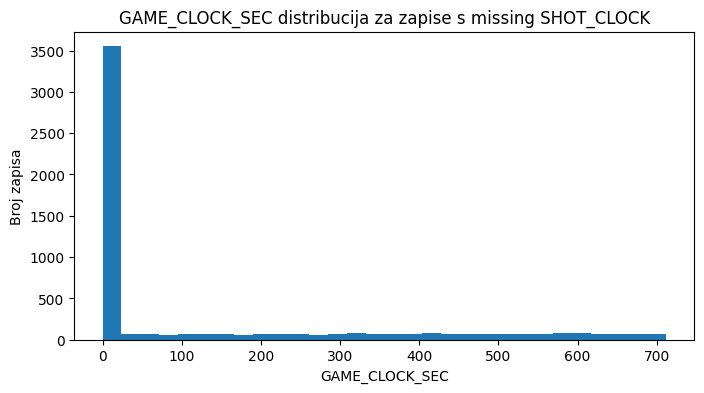

In [9]:
df_imp2 = df.copy()
df_imp2["SHOT_CLOCK_MISSING"] = df_imp2["SHOT_CLOCK"].isna().astype(int)

mask_end_period = df_imp2["SHOT_CLOCK"].isna() & (df_imp2["GAME_CLOCK_SEC"].astype('float') < 24)
df_imp2.loc[mask_end_period, "SHOT_CLOCK"] = df_imp2.loc[mask_end_period, "GAME_CLOCK_SEC"].astype('float')

mask_shotclock_violation = df_imp2["SHOT_CLOCK"].isna()
df_imp2.loc[mask_shotclock_violation, "SHOT_CLOCK"] = 0

print("Preostalo NaN u SHOT_CLOCK nakon pravila:", df_imp2["SHOT_CLOCK"].isna().sum())
print("Koliko slučajeva je bilo kraj perioda (GAME_CLOCK_SEC<24):", int(mask_end_period.sum()))

plt.figure(figsize=(8,4))
plt.hist(df.loc[df["SHOT_CLOCK"].isna(), "GAME_CLOCK_SEC"].dropna().astype(int), bins=30)
plt.title("GAME_CLOCK_SEC distribucija za zapise s missing SHOT_CLOCK")
plt.xlabel("GAME_CLOCK_SEC")
plt.ylabel("Broj zapisa")
plt.show()


## 6) Vizualizacije


Prikazat ćemo:
- raspodjelu distance šuta (`SHOT_DIST`)
- odnos `SHOT_DIST` i postotka pogođenih šuteva
- utjecaj obrambene distance (`CLOSE_DEF_DIST`) na uspješnost
- distribuciju driblinga i touch time
- 2PT vs 3PT uspješnost


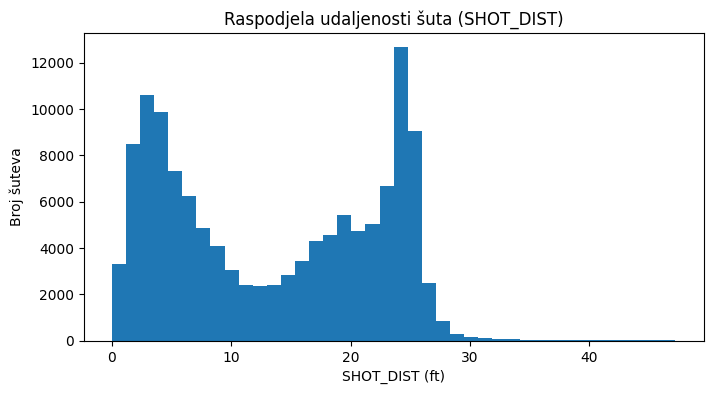

/tmp/ipython-input-9638984.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fg_by_bin = df_tmp.groupby("SHOT_DIST_BIN")["FGM"].mean()


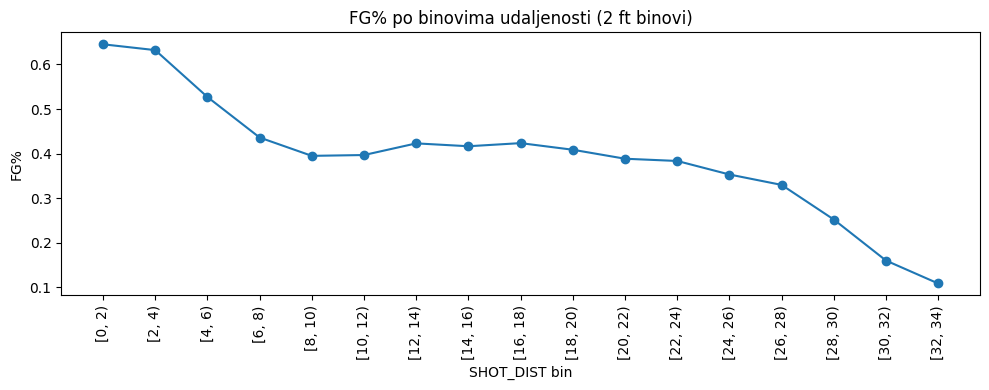

In [10]:
plt.figure(figsize=(8,4))
plt.hist(df["SHOT_DIST"].dropna(), bins=40)
plt.title("Raspodjela udaljenosti šuta (SHOT_DIST)")
plt.xlabel("SHOT_DIST (ft)")
plt.ylabel("Broj šuteva")
plt.show()

df_drop=df.dropna(subset=["SHOT_CLOCK"]).copy()

bins = np.arange(0, 35, 2)
df_tmp = df_drop.copy()
df_tmp["SHOT_DIST_BIN"] = pd.cut(df_tmp["SHOT_DIST"], bins=bins, right=False)
fg_by_bin = df_tmp.groupby("SHOT_DIST_BIN")["FGM"].mean()

plt.figure(figsize=(10,4))
plt.plot(range(len(fg_by_bin)), fg_by_bin.values, marker='o')
plt.xticks(range(len(fg_by_bin)), [str(b) for b in fg_by_bin.index], rotation=90)
plt.title("FG% po binovima udaljenosti (2 ft binovi)")
plt.xlabel("SHOT_DIST bin")
plt.ylabel("FG%")
plt.tight_layout()
plt.show()

/tmp/ipython-input-3375504833.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fg_by_def = df_tmp.groupby("DEF_DIST_BIN")["FGM"].mean()


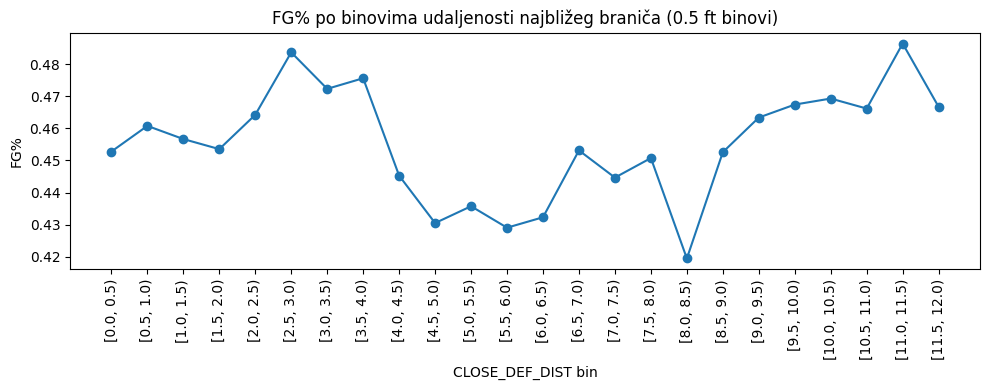

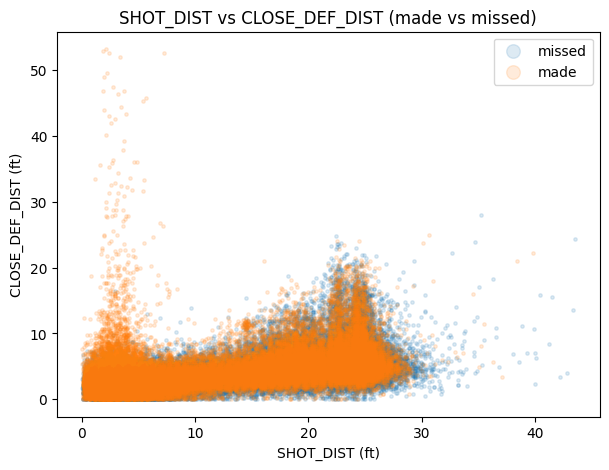

In [11]:
bins = np.arange(0, 12.5, 0.5)
df_tmp = df_drop.copy()
df_tmp["DEF_DIST_BIN"] = pd.cut(df_tmp["CLOSE_DEF_DIST"], bins=bins, right=False)
fg_by_def = df_tmp.groupby("DEF_DIST_BIN")["FGM"].mean()

plt.figure(figsize=(10,4))
plt.plot(range(len(fg_by_def)), fg_by_def.values, marker='o')
plt.xticks(range(len(fg_by_def)), [str(b) for b in fg_by_def.index], rotation=90)
plt.title("FG% po binovima udaljenosti najbližeg braniča (0.5 ft binovi)")
plt.xlabel("CLOSE_DEF_DIST bin")
plt.ylabel("FG%")
plt.tight_layout()
plt.show()

made = df_drop[df_drop["FGM"]==1]
miss = df_drop[df_drop["FGM"]==0]

plt.figure(figsize=(7,5))
plt.scatter(miss["SHOT_DIST"], miss["CLOSE_DEF_DIST"], s=6, alpha=0.15, label="missed")
plt.scatter(made["SHOT_DIST"], made["CLOSE_DEF_DIST"], s=6, alpha=0.15, label="made")
plt.title("SHOT_DIST vs CLOSE_DEF_DIST (made vs missed)")
plt.xlabel("SHOT_DIST (ft)")
plt.ylabel("CLOSE_DEF_DIST (ft)")
plt.legend(markerscale=4)
plt.show()

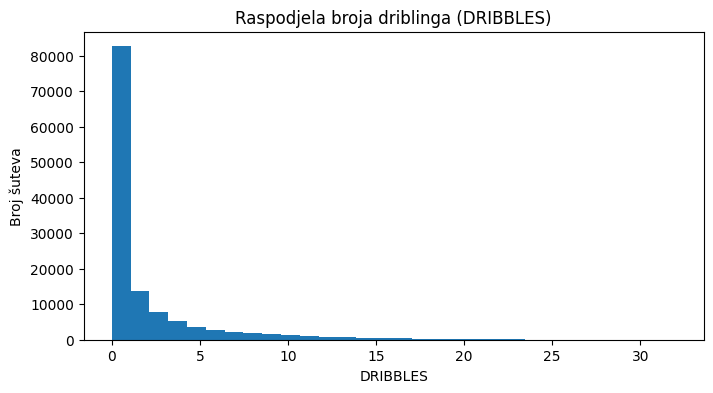

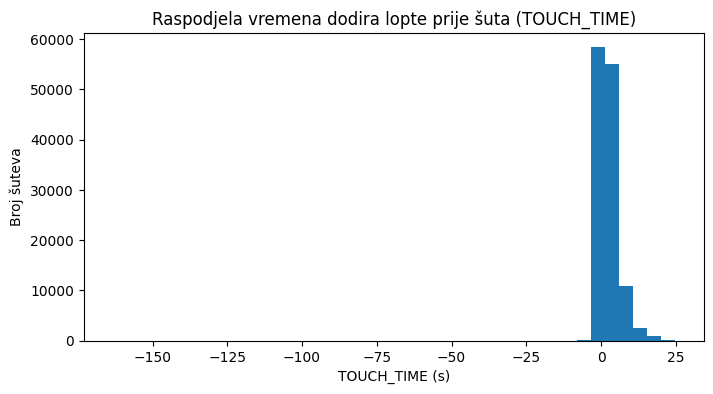

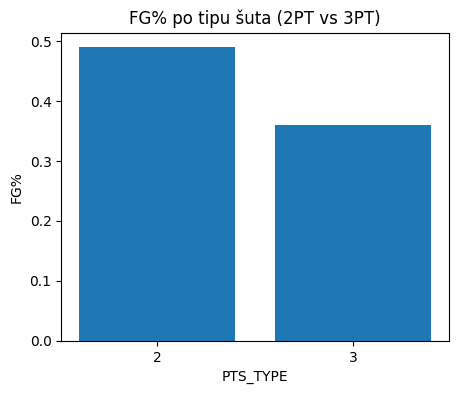

In [12]:
plt.figure(figsize=(8,4))
plt.hist(df["DRIBBLES"], bins=30)
plt.title("Raspodjela broja driblinga (DRIBBLES)")
plt.xlabel("DRIBBLES")
plt.ylabel("Broj šuteva")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(df["TOUCH_TIME"].dropna(), bins=40)
plt.title("Raspodjela vremena dodira lopte prije šuta (TOUCH_TIME)")
plt.xlabel("TOUCH_TIME (s)")
plt.ylabel("Broj šuteva")
plt.show()

fg_by_pts = df_drop.groupby("PTS_TYPE")["FGM"].mean().sort_index()
plt.figure(figsize=(5,4))
plt.bar([str(k) for k in fg_by_pts.index], fg_by_pts.values)
plt.title("FG% po tipu šuta (2PT vs 3PT)")
plt.xlabel("PTS_TYPE")
plt.ylabel("FG%")
plt.show()

### 6.1) `TOUCH_TIME` i negativne vrijednosti

U boxplotovima/histogramima možemo uočiti da `TOUCH_TIME` ponekad poprima **negativne vrijednosti**. Negativno vrijeme kontakta igrača s loptom nema fizičkog smisla, pa je to vrlo vjerojatno **greška mjerenja / artefakt trackinga**.

U takvim situacijama najčešći pristupi su:
- postaviti negativne vrijednosti na `NaN` pa imputirati (npr. medianom) ili
- **clip** na 0 (pretpostavka da je realna vrijednost bila blizu 0)

U nastavku prikazujemo koliko takvih slučajeva ima te radimo konzervativni pristup: clip na 0 i dodajemo indikator.

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

col = "TOUCH_TIME"

n_total = len(df)
n_missing = df[col].isna().sum()
n_negative = (df[col] < 0).sum()

print(f"[{col}] ukupno: {n_total:,}")
print(f"[{col}] missing: {n_missing:,} ({n_missing/n_total:.2%})")
print(f"[{col}] negativno: {n_negative:,} ({n_negative/n_total:.2%})")

if n_negative > 0:
    neg_vals = df.loc[df[col] < 0, col]
    print(f"[{col}] min negativno: {neg_vals.min():.6f}")
    print(f"[{col}] 1% / 5% / 50% / 95% / 99% negativnih: "
          f"{np.percentile(neg_vals.dropna(), [1,5,50,95,99])}")


[TOUCH_TIME] ukupno: 128,069
[TOUCH_TIME] missing: 0 (0.00%)
[TOUCH_TIME] negativno: 312 (0.24%)
[TOUCH_TIME] min negativno: -163.600000
[TOUCH_TIME] 1% / 5% / 50% / 95% / 99% negativnih: [-13.325  -7.635  -0.4    -0.1    -0.1  ]


In [14]:
df[f"{col}_was_negative"] = (df[col] < 0).astype(int)

df[col] = df[col].clip(lower=0)

print("Nakon clip-a:")
print(f"  negativno: {(df[col] < 0).sum()} (treba biti 0)")
print(f"  indikator 1-ica: {df[f'{col}_was_negative'].sum():,}")


Nakon clip-a:
  negativno: 0 (treba biti 0)
  indikator 1-ica: 312


## 7) Jednostavne usporedbe i korelacije
Pogledajmo korelacije numeričkih varijabli (bez `GAME_ID` i ID-eva), i nekoliko zanimljivih rezova:
- FG% po periodu
- FG% po `SHOT_NUMBER` (u okviru utakmice)


### 7.1) `W` (WIN) i `FINAL_MARGIN`: korelacija i problem kauzalnosti

Stupci `W` (pobjeda/poraz) i `FINAL_MARGIN` (konačna razlika) su **visoko povezani međusobno**, a ujedno su povezani i s ciljem (pogođen/promašen šut). Međutim, važno je naglasiti problem **kauzalnosti**:

- Pogođeni šutevi *doprinose* pobjedi i većoj završnoj razlici.
- To znači da `W` i `FINAL_MARGIN` djelomično sadrže informaciju koja je **posljedica** pogođenih šuteva, a ne uzrok.

Ako gradimo model koji predviđa ishod šuta *u trenutku izvođenja*, korištenje `W` i `FINAL_MARGIN` može predstavljati **curenje informacija (target leakage)**. U ovom notebooku ih zadržavamo za deskriptivnu analizu, ali bismo ih u produkcijskom prediktivnom modelu tipično izbacili ili zamijenili varijablama dostupnim u trenutku šuta (npr. trenutna razlika u poenima).

,W_num,FINAL_MARGIN,FGM
W_num,1.000000,0.809887,0.050239
FINAL_MARGIN,0.809887,1.000000,0.058762
FGM,0.050239,0.058762,1.000000


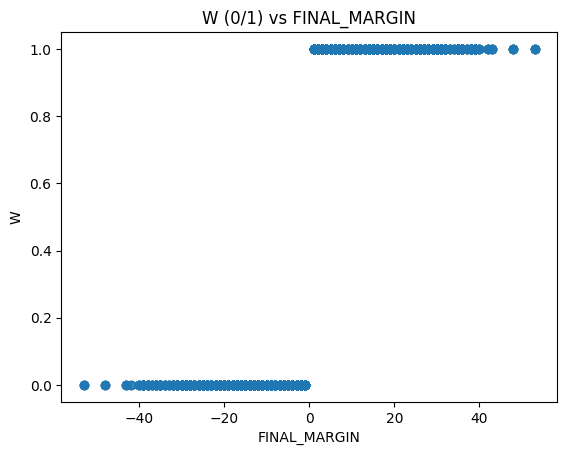

In [16]:
tmp = df.copy()
tmp["W_num"] = tmp["W"].map({"W": 1, "L": 0})

sub = tmp[["W_num", "FINAL_MARGIN", "FGM"]].dropna()
display(sub.corr())

plt.scatter(sub["FINAL_MARGIN"], sub["W_num"], alpha=0.05)
plt.title("W (0/1) vs FINAL_MARGIN")
plt.xlabel("FINAL_MARGIN")
plt.ylabel("W")
plt.show()

Broj negativnih TOUCH_TIME vrijednosti: 312


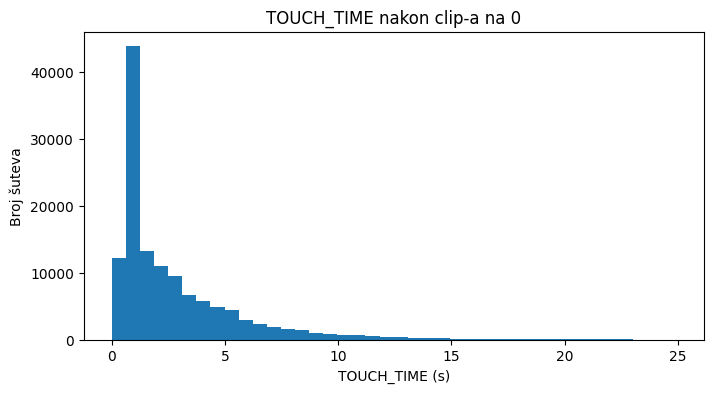

In [ ]:
neg_tt = (df["TOUCH_TIME"] < 0).sum()
print("Broj negativnih TOUCH_TIME vrijednosti:", int(neg_tt))

df_tt = df.copy()
df_tt["TOUCH_TIME_NEGATIVE"] = (df_tt["TOUCH_TIME"] < 0).astype(int)
# clip na 0
df_tt.loc[df_tt["TOUCH_TIME"] < 0, "TOUCH_TIME"] = 0

plt.figure(figsize=(8,4))
plt.hist(df_tt["TOUCH_TIME"].dropna(), bins=40)
plt.title("TOUCH_TIME nakon clip-a na 0")
plt.xlabel("TOUCH_TIME (s)")
plt.ylabel("Broj šuteva")
plt.show()


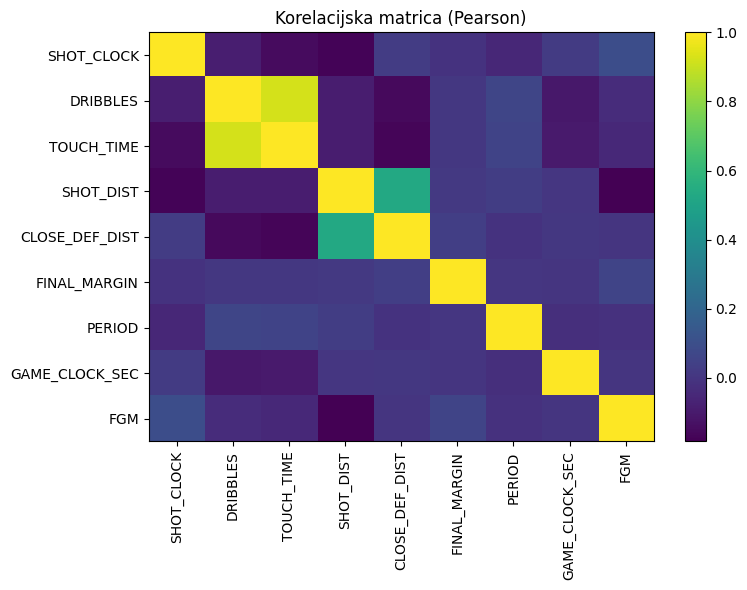

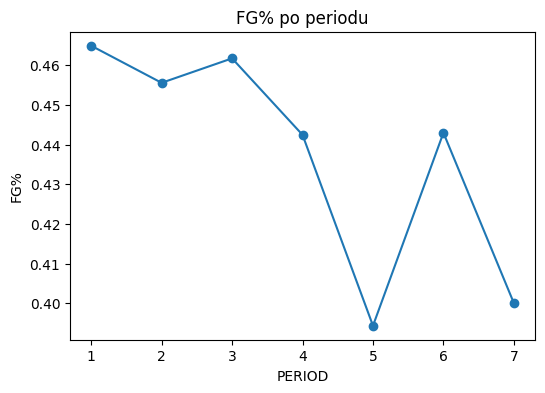

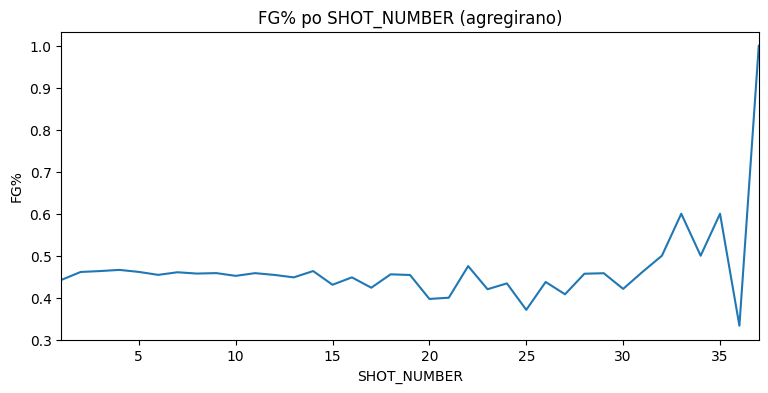

In [ ]:
corr_cols = ["SHOT_CLOCK","DRIBBLES","TOUCH_TIME","SHOT_DIST","CLOSE_DEF_DIST","FINAL_MARGIN","PERIOD","GAME_CLOCK_SEC","FGM"]
corr = df_drop[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Korelacijska matrica (Pearson)")
plt.colorbar()
plt.tight_layout()
plt.show()

fg_by_period = df_drop.groupby("PERIOD")["FGM"].mean().sort_index()
plt.figure(figsize=(6,4))
plt.plot(fg_by_period.index.astype(int), fg_by_period.values, marker='o')
plt.title("FG% po periodu")
plt.xlabel("PERIOD")
plt.ylabel("FG%")
plt.xticks(fg_by_period.index.astype(int))
plt.show()

fg_by_shotnum = df_drop.groupby("SHOT_NUMBER")["FGM"].mean()
plt.figure(figsize=(9,4))
plt.plot(fg_by_shotnum.index, fg_by_shotnum.values)
plt.title("FG% po SHOT_NUMBER (agregirano)")
plt.xlabel("SHOT_NUMBER")
plt.ylabel("FG%")
plt.xlim(1, min(60, fg_by_shotnum.index.max()))
plt.show()

## 8) Kratki zaključci (što smo naučili iz podataka)
- Udaljenost šuta (`SHOT_DIST`) i udaljenost braniča (`CLOSE_DEF_DIST`) su snažno povezani s vjerojatnošću pogođenog šuta.
- `PTS_TYPE` (2 vs 3) pokazuje očekivano različite postotke.
- `DRIBBLES` i `TOUCH_TIME` imaju dugačke repove (neke ekstremne vrijednosti)



# Treniranje klasifikacijskih modela

#### 0.1) Priprema jedinstvenog skupa podataka za modeliranje (df_model)

U bilježnici se paralelno stvaraju različiti DataFrame-ovi (`df_ohe`, `df_imp2`, `df_tt`, ...). To je korisno za analizu, ali za treniranje više modela je praktično imati **jedan** DataFrame koji sadrži sve odabrane transformacije.

U nastavku gradimo `df_model` tako da se *sve ključne promjene* (SHOT_CLOCK imputacija + indikator, uklanjanje/klipanje negativnog TOUCH_TIME, LOCATION u binarnu varijablu i one-hot za PERIOD/LOCATION) nalaze na jednom mjestu.


In [ ]:
df_model = df.copy()

df_model["IS_HOME"] = df_model["LOCATION"].map({"H": 1, "A": 0}).astype("Int64")

df_model["SHOT_CLOCK_MISSING"] = df_model["SHOT_CLOCK"].isna().astype(int)

mask_end_period = df_model["SHOT_CLOCK"].isna() & (df_model["GAME_CLOCK_SEC"].astype(float) < 24)
df_model.loc[mask_end_period, "SHOT_CLOCK"] = df_model.loc[mask_end_period, "GAME_CLOCK_SEC"].astype(float)

mask_shotclock_violation = df_model["SHOT_CLOCK"].isna()
df_model.loc[mask_shotclock_violation, "SHOT_CLOCK"] = 0

df_model["TOUCH_TIME_NEGATIVE"] = (df_model["TOUCH_TIME"] < 0).astype(int)
df_model.loc[df_model["TOUCH_TIME"] < 0, "TOUCH_TIME"] = 0


df_model = pd.get_dummies(df_model, columns=["PERIOD", "LOCATION"], drop_first=False)

print("df_model shape:", df_model.shape)
print("NaN u SHOT_CLOCK:", df_model["SHOT_CLOCK"].isna().sum())
print("Primjer one-hot stupaca:", [c for c in df_model.columns if c.startswith("PERIOD_") or c.startswith("LOCATION_")][:10])

df_model shape: (128069, 38)
NaN u SHOT_CLOCK: 0
Primjer one-hot stupaca: ['PERIOD_1', 'PERIOD_2', 'PERIOD_3', 'PERIOD_4', 'PERIOD_5', 'PERIOD_6', 'PERIOD_7', 'LOCATION_A', 'LOCATION_H']


#### 0.2) Skup podataka sortiran po datumu utakmica

In [ ]:
df_model_sorted = df_model.sort_values("GAME_DATE").reset_index(drop=True)

n = len(df_model_sorted)

train_end = int(0.7 * n)
val_end   = int(0.8 * n)

train_df = df_model_sorted.iloc[:train_end]
val_df   = df_model_sorted.iloc[train_end:val_end]
test_df  = df_model_sorted.iloc[val_end:]

feature_cols = [
    "SHOT_DIST",
    "SHOT_CLOCK",
    "SHOT_CLOCK_MISSING",
    "CLOSE_DEF_DIST",
    "DRIBBLES",
    "TOUCH_TIME",
    "GAME_CLOCK_SEC",
    "IS_HOME",
    "PERIOD_1", "PERIOD_2", "PERIOD_3", "PERIOD_4"
]

X_train = train_df[feature_cols]
y_train = train_df["FGM"]

X_val = val_df[feature_cols]
y_val = val_df["FGM"]

X_test = test_df[feature_cols]
y_test = test_df["FGM"]


## 1) Logistička regresija

#### 1.1) Točnost

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

clf_weighted = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="lbfgs"
)

clf_weighted.fit(X_train, y_train)
y_pred_w = clf_weighted.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred_w))


Accuracy: 0.5894432732099633


#### 1.2) Matrica Zabune

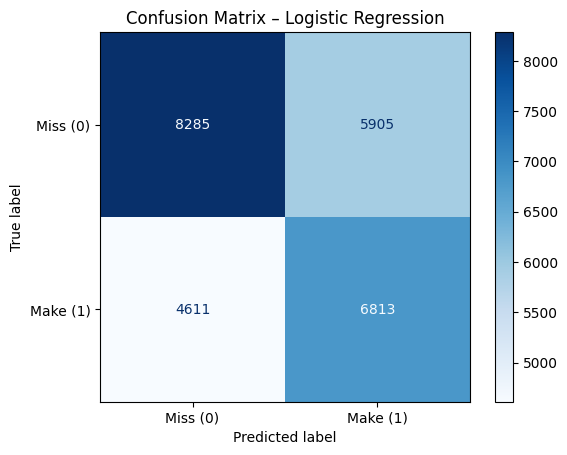

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred_w)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Miss (0)", "Make (1)"]
)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix – Logistic Regression")
plt.show()

#### 1.3) Preciznost

In [ ]:
from sklearn.metrics import classification_report, precision_score, recall_score

print(classification_report(y_test, y_pred_w))

precision = precision_score(y_test, y_pred_w)
recall = recall_score(y_test, y_pred_w)

print("Precision:", precision)
print("Recall:", recall)

              precision    recall  f1-score   support

           0       0.64      0.58      0.61     14190
           1       0.54      0.60      0.56     11424

    accuracy                           0.59     25614
   macro avg       0.59      0.59      0.59     25614
weighted avg       0.59      0.59      0.59     25614

Precision: 0.5356974367038843
Recall: 0.5963760504201681


#### 1.4) ROC krivulja

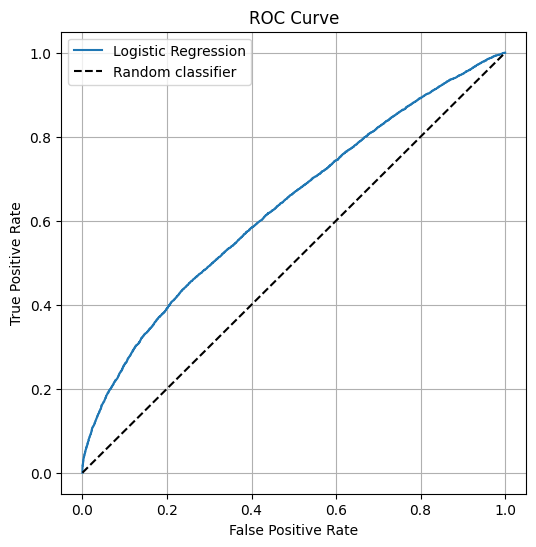

In [ ]:
from sklearn.metrics import roc_curve

y_prob = clf_weighted.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

#### 1.5) ROC-AUC točnost

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)

AUC: 0.6343211249439875


## 2) SVM
## 2.1) Linear kernal

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

X_train_SVM, X_validate, y_train_SVM, y_validate = train_test_split( X_train, y_train, test_size=0.1, random_state=42, stratify=y_train )

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", LinearSVC(
        dual="auto",
        max_iter=5000,
        class_weight="balanced"
    ))
])

param_grid = {"svm__C": [0.01, 0.1, 1, 10]}

grid = GridSearchCV(
    pipe, param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=1,
    verbose=2
)

grid.fit(X_train_SVM, y_train_SVM)

print("Best params:", grid.best_params_)
best_svm = grid.best_estimator_

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ........................................svm__C=0.01; total time=   0.1s
[CV] END ........................................svm__C=0.01; total time=   0.0s
[CV] END ........................................svm__C=0.01; total time=   0.1s
[CV] END .........................................svm__C=0.1; total time=   0.0s
[CV] END .........................................svm__C=0.1; total time=   0.0s
[CV] END .........................................svm__C=0.1; total time=   0.0s
[CV] END ...........................................svm__C=1; total time=   0.1s
[CV] END ...........................................svm__C=1; total time=   0.0s
[CV] END ...........................................svm__C=1; total time=   0.1s
[CV] END ..........................................svm__C=10; total time=   0.0s
[CV] END ..........................................svm__C=10; total time=   0.0s
[CV] END ........................................

#### 2.1.1) Točnost

In [ ]:
best_svm = grid.best_estimator_

y_val_pred = best_svm.predict(X_validate)
y_val_score = best_svm.decision_function(X_validate)
print("Validation accuracy:", accuracy_score(y_validate, y_val_pred))

y_test_pred = best_svm.predict(X_test)
y_test_score = best_svm.decision_function(X_test)
print("Test accuracy:", accuracy_score(y_test, y_test_pred))

y_pred_svm = best_svm.predict(X_test)

Validation accuracy: 0.5868377021751255
Test accuracy: 0.5888576559693918


#### 2.1.2) Matrica Zabune

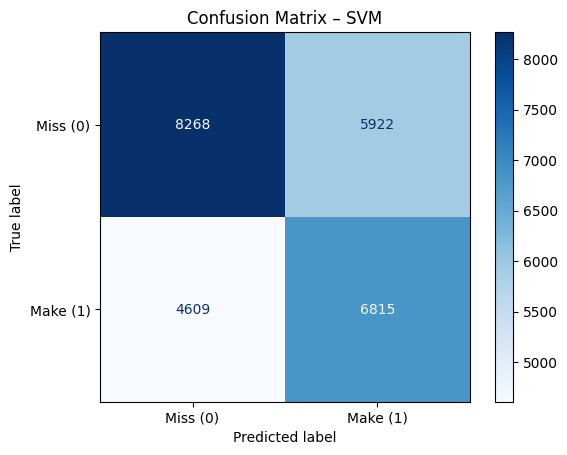

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Miss (0)", "Make (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – SVM")
plt.show()


#### 2.1.3) Preciznost

In [ ]:
print(classification_report(y_test, y_pred_svm))

precision = precision_score(y_test, y_pred_svm)
recall = recall_score(y_test, y_pred_svm)

print("Precision:", precision)
print("Recall:", recall)

              precision    recall  f1-score   support

           0       0.64      0.58      0.61     14190
           1       0.54      0.60      0.56     11424

    accuracy                           0.59     25614
   macro avg       0.59      0.59      0.59     25614
weighted avg       0.59      0.59      0.59     25614

Precision: 0.5350553505535055
Recall: 0.5965511204481793


#### 2.1.4) ROC krivulja

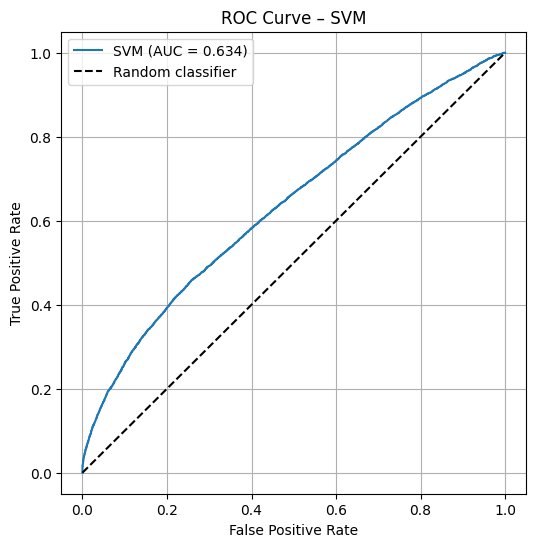

In [ ]:
y_score = best_svm.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"SVM (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SVM")
plt.legend()
plt.grid(True)
plt.show()

#### 2.1.5) ROC-AUC točnost

In [ ]:
print("Validation AUC:", roc_auc_score(y_validate, y_val_score))

print("Test AUC:", roc_auc_score(y_test, y_test_score))

Validation AUC: 0.6338132866472515
Test AUC: 0.6343682297619542


### 2.2) RBF kernel

Također smo pri testiranju SVM modela isprobali i RBF kernel zbog mogućnosti nelinearnih granica između klasa. Zbog sporosti samog procesa, morali smo koristiti podskup.

#### 2.2.0) Dodavanje podskupova

In [ ]:
import numpy as np

n = len(X_train)
n_sub = min(20000, n)  # 10k–20k is usually manageable
idx = np.random.RandomState(42).choice(n, size=n_sub, replace=False)

X_sub = X_train.iloc[idx] if hasattr(X_train, "iloc") else X_train[idx]
y_sub = y_train.iloc[idx] if hasattr(y_train, "iloc") else y_train[idx]


#### 2.2.1) Grid search + Treniranje modela

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, roc_auc_score

pipe_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(kernel="rbf", class_weight="balanced"))
])

param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__gamma": ["scale", 0.01, 0.1]
}

grid = GridSearchCV(
    pipe_rbf,
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=1,
    verbose=2
)

grid.fit(X_sub, y_sub)

print("Best params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

best_rbf = grid.best_estimator_


Fitting 3 folds for each of 9 candidates, totalling 27 fits
[CV] END .......................svc__C=0.1, svc__gamma=scale; total time=  20.2s
[CV] END .......................svc__C=0.1, svc__gamma=scale; total time=  18.6s
[CV] END .......................svc__C=0.1, svc__gamma=scale; total time=  19.4s
[CV] END ........................svc__C=0.1, svc__gamma=0.01; total time=  19.1s
[CV] END ........................svc__C=0.1, svc__gamma=0.01; total time=  19.0s
[CV] END ........................svc__C=0.1, svc__gamma=0.01; total time=  20.3s
[CV] END .........................svc__C=0.1, svc__gamma=0.1; total time=  21.1s
[CV] END .........................svc__C=0.1, svc__gamma=0.1; total time=  20.3s
[CV] END .........................svc__C=0.1, svc__gamma=0.1; total time=  18.3s
[CV] END .........................svc__C=1, svc__gamma=scale; total time=  17.9s
[CV] END .........................svc__C=1, svc__gamma=scale; total time=  18.0s
[CV] END .........................svc__C=1, svc__

#### 2.2.2) Acuracy

In [ ]:
y_test_pred = best_rbf.predict(X_test)
y_test_score = best_rbf.decision_function(X_test)

print("Test accuracy:", accuracy_score(y_test, y_test_pred))

Test accuracy: 0.5963145154993363


#### 2.2.3) Matrica zabune

In [ ]:
import numpy as np
from sklearn.metrics import f1_score

scores_val = best_rbf.decision_function(X_validate)
ths = np.linspace(scores_val.min(), scores_val.max(), 200)

f1s = [f1_score(y_validate, (scores_val > t).astype(int)) for t in ths]
best_t = ths[np.argmax(f1s)]
print("Best threshold:", best_t, "Best F1:", max(f1s))

scores_test = best_rbf.decision_function(X_test)
y_test_pred_thr = (scores_test > best_t).astype(int)


Best threshold: -1.141595366598155 Best F1: 0.629649933432532


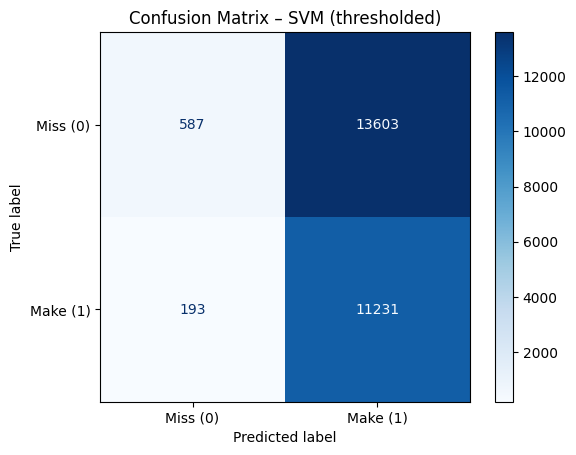

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_test_pred_thr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=["Miss (0)", "Make (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix – SVM (thresholded)")
plt.show()

#### 2.2.4) ROC krivulja + AUC

Test AUC: 0.6289794472228638


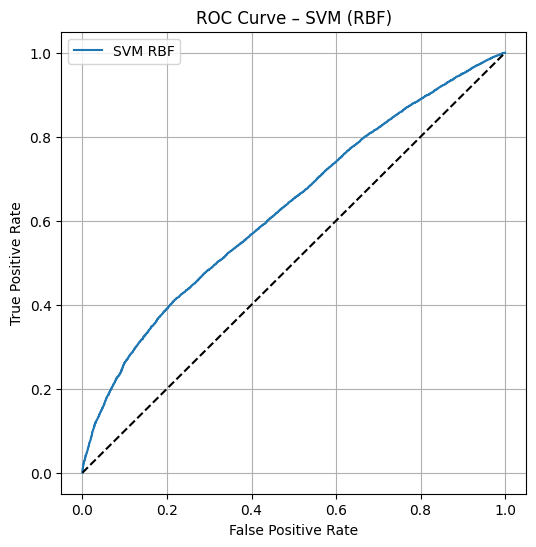

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

print("Test AUC:", roc_auc_score(y_test, y_test_score))

fpr, tpr, _ = roc_curve(y_test, y_test_score)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="SVM RBF")
plt.plot([0,1],[0,1],"k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – SVM (RBF)")
plt.legend()
plt.grid(True)
plt.show()


## 3) Naive Bayes

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params (NB): {'alpha': 6.351221010640703}

Validation accuracy: 0.5714445064138316
Validation AUC: 0.5996013847269598

Validation report:
               precision    recall  f1-score   support

           0       0.62      0.56      0.59      4886
           1       0.53      0.58      0.55      4079

    accuracy                           0.57      8965
   macro avg       0.57      0.57      0.57      8965
weighted avg       0.58      0.57      0.57      8965


Test accuracy: 0.5687514640431014
Test AUC: 0.5957796803534663

Test report:
               precision    recall  f1-score   support

           0       0.62      0.55      0.59     14190
           1       0.51      0.59      0.55     11424

    accuracy                           0.57     25614
   macro avg       0.57      0.57      0.57     25614
weighted avg       0.58      0.57      0.57     25614



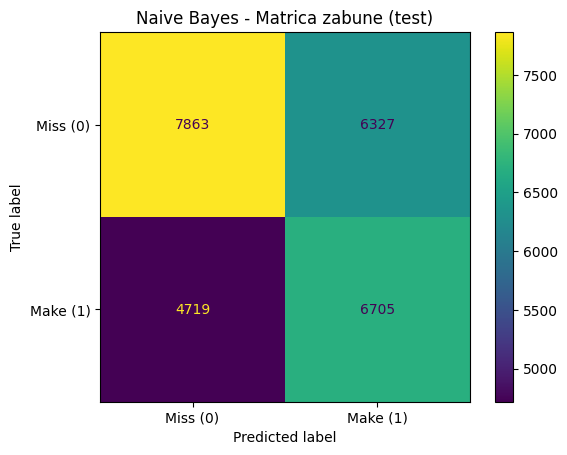

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import loguniform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_train_nb_full, X_validate_nb_full, y_train_nb, y_validate_nb = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

def apply_paper_binning(X_tr: pd.DataFrame, X_te: pd.DataFrame, cont_vars):
    X_tr_b = X_tr.copy()
    X_te_b = X_te.copy()

    for col in cont_vars:
        mean = X_tr_b[col].mean()
        std = X_tr_b[col].std()
        bins = [-np.inf, mean - std, mean, mean + std, np.inf]

        X_tr_b[col] = pd.cut(X_tr_b[col], bins=bins, labels=[0, 1, 2, 3]).astype(int)
        X_te_b[col] = pd.cut(X_te_b[col], bins=bins, labels=[0, 1, 2, 3]).astype(int)

    return X_tr_b, X_te_b

cont_vars = ["SHOT_DIST", "CLOSE_DEF_DIST", "SHOT_CLOCK", "DRIBBLES", "TOUCH_TIME"]

X_train_nb, X_validate_nb = apply_paper_binning(X_train_nb_full, X_validate_nb_full, cont_vars)
_, X_test_nb = apply_paper_binning(X_train_nb_full, X_test, cont_vars)  # binovi iz traina

classes = np.unique(y_train_nb)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_nb)
cw = dict(zip(classes, class_weights))
sample_weight_nb = np.array([cw[int(label)] for label in y_train_nb])

nb = MultinomialNB()

param_dist_nb = {
    "alpha": loguniform(1e-3, 10.0)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_nb = RandomizedSearchCV(
    nb,
    param_distributions=param_dist_nb,
    n_iter=20,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_nb.fit(X_train_nb, y_train_nb, sample_weight=sample_weight_nb)

print("Best params (NB):", search_nb.best_params_)
best_nb = search_nb.best_estimator_

y_val_pred = best_nb.predict(X_validate_nb)
y_val_prob = best_nb.predict_proba(X_validate_nb)[:, 1]

print("\nValidation accuracy:", accuracy_score(y_validate_nb, y_val_pred))
print("Validation AUC:", roc_auc_score(y_validate_nb, y_val_prob))
print("\nValidation report:\n", classification_report(y_validate_nb, y_val_pred))

y_test_pred = best_nb.predict(X_test_nb)
y_test_prob = best_nb.predict_proba(X_test_nb)[:, 1]

print("\nTest accuracy:", accuracy_score(y_test, y_test_pred))
print("Test AUC:", roc_auc_score(y_test, y_test_prob))
print("\nTest report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Miss (0)", "Make (1)"]).plot(values_format="d")
plt.title("Naive Bayes - Matrica zabune (test)")
plt.show()


## 4) Neuronske mreže

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best params (MLP): {'mlp__activation': 'tanh', 'mlp__alpha': 0.006708188643346287, 'mlp__hidden_layer_sizes': (128,), 'mlp__learning_rate_init': 0.004138040112561018, 'mlp__solver': 'adam'}

Validation accuracy: 0.6126045733407697
Validation AUC: 0.6397306491913646

Validation report:
               precision    recall  f1-score   support

           0       0.62      0.76      0.68      4886
           1       0.60      0.43      0.50      4079

    accuracy                           0.61      8965
   macro avg       0.61      0.60      0.59      8965
weighted avg       0.61      0.61      0.60      8965


Test accuracy: 0.616811118919341
Test AUC: 0.6373917224571295

Test report:
               precision    recall  f1-score   support

           0       0.63      0.76      0.69     14190
           1       0.60      0.44      0.50     11424

    accuracy                           0.62     25614
   macro avg       0.61      

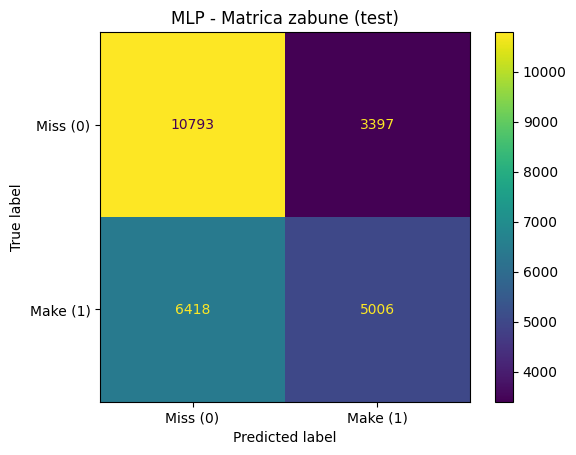

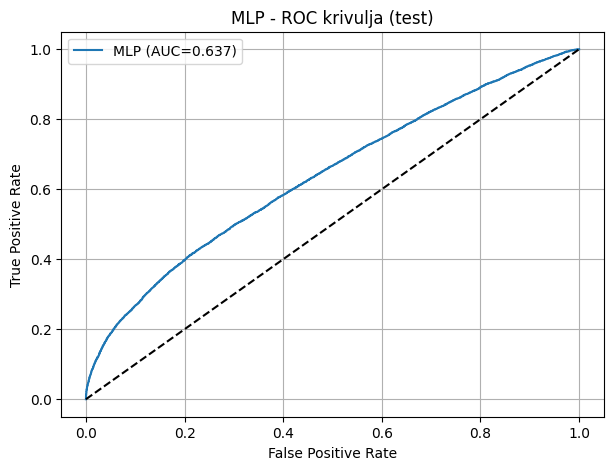

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from sklearn.utils.class_weight import compute_class_weight
from scipy.stats import loguniform
import numpy as np
import matplotlib.pyplot as plt

X_train_mlp, X_validate_mlp, y_train_mlp, y_validate_mlp = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

classes = np.unique(y_train_mlp)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_mlp)
cw = dict(zip(classes, class_weights))
sample_weight_mlp = np.array([cw[int(label)] for label in y_train_mlp])

pipe_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPClassifier(
        random_state=42,
        early_stopping=True,
        n_iter_no_change=10,
        max_iter=200
    ))
])

param_dist_mlp = {
    "mlp__hidden_layer_sizes": [(64,), (128,), (64, 64), (128, 64)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__alpha": loguniform(1e-5, 1e-2),
    "mlp__solver": ["adam"],
    "mlp__learning_rate_init": loguniform(1e-4, 1e-2)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_mlp = RandomizedSearchCV(
    pipe_mlp,
    param_distributions=param_dist_mlp,
    n_iter=25,          # << tipično 5–10× brže od grida
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_mlp.fit(X_train_mlp, y_train_mlp, mlp__sample_weight=sample_weight_mlp)

print("Best params (MLP):", search_mlp.best_params_)
best_mlp = search_mlp.best_estimator_

y_val_pred = best_mlp.predict(X_validate_mlp)
y_val_prob = best_mlp.predict_proba(X_validate_mlp)[:, 1]

print("\nValidation accuracy:", accuracy_score(y_validate_mlp, y_val_pred))
print("Validation AUC:", roc_auc_score(y_validate_mlp, y_val_prob))
print("\nValidation report:\n", classification_report(y_validate_mlp, y_val_pred))

y_test_pred = best_mlp.predict(X_test)
y_test_prob = best_mlp.predict_proba(X_test)[:, 1]

print("\nTest accuracy:", accuracy_score(y_test, y_test_pred))
print("Test AUC:", roc_auc_score(y_test, y_test_prob))
print("\nTest report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Miss (0)", "Make (1)"]).plot(values_format="d")
plt.title("MLP - Matrica zabune (test)")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"MLP (AUC={roc_auc_score(y_test, y_test_prob):.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MLP - ROC krivulja (test)")
plt.legend()
plt.grid(True)
plt.show()


## 5) Slučajna šuma (Random Forest)


Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params (RF): {'max_depth': 12, 'max_features': 'log2', 'min_samples_leaf': 5, 'min_samples_split': 3, 'n_estimators': 543}

Validation accuracy: 0.6184049079754601
Validation AUC: 0.6475344648874455

Validation report:
               precision    recall  f1-score   support

           0       0.62      0.78      0.69      4886
           1       0.62      0.42      0.50      4079

    accuracy                           0.62      8965
   macro avg       0.62      0.60      0.60      8965
weighted avg       0.62      0.62      0.60      8965


Test accuracy: 0.6181385179979698
Test AUC: 0.6433972351273138

Test report:
               precision    recall  f1-score   support

           0       0.63      0.78      0.69     14190
           1       0.60      0.42      0.50     11424

    accuracy                           0.62     25614
   macro avg       0.61      0.60      0.59     25614
weighted avg       0.62      0.62   

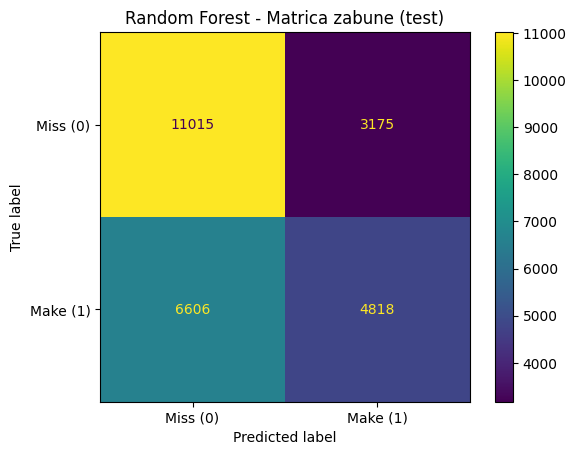

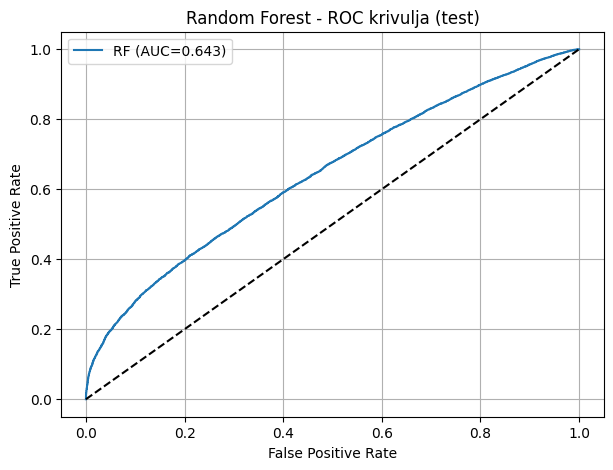

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve
from scipy.stats import randint
import numpy as np
import matplotlib.pyplot as plt

X_train_rf, X_validate_rf, y_train_rf, y_validate_rf = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

param_dist_rf = {
    "n_estimators": randint(200, 900),
    "max_depth": [None, 8, 12, 16, 20],
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 11),
    "max_features": ["sqrt", "log2", 0.5]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_rf = RandomizedSearchCV(
    rf,
    param_distributions=param_dist_rf,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_rf.fit(X_train_rf, y_train_rf)

print("Best params (RF):", search_rf.best_params_)
best_rf = search_rf.best_estimator_

y_val_pred = best_rf.predict(X_validate_rf)
y_val_prob = best_rf.predict_proba(X_validate_rf)[:, 1]

print("\nValidation accuracy:", accuracy_score(y_validate_rf, y_val_pred))
print("Validation AUC:", roc_auc_score(y_validate_rf, y_val_prob))
print("\nValidation report:\n", classification_report(y_validate_rf, y_val_pred))

y_test_pred = best_rf.predict(X_test)
y_test_prob = best_rf.predict_proba(X_test)[:, 1]

print("\nTest accuracy:", accuracy_score(y_test, y_test_pred))
print("Test AUC:", roc_auc_score(y_test, y_test_prob))
print("\nTest report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Miss (0)", "Make (1)"]).plot(values_format="d")
plt.title("Random Forest - Matrica zabune (test)")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"RF (AUC={roc_auc_score(y_test, y_test_prob):.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest - ROC krivulja (test)")
plt.legend()
plt.grid(True)
plt.show()


## 6. Boosting metoda
Boosting je pristup u strojnome učenju koji kombinira više slabih klasifikatora (weak learners) u jedan snažan klasifikator (strong learner).
Slabi klasifikatori su klasifikatori koji rade nešto bolje od slučajnog pogađanja, ali ne puno — primjerice imaju točnost oko 50–60 %. Često se kao slabi klasifikatori koriste stabla odlučivanja, ali vrlo jednostavna (plitka stabla).


In [ ]:
period_cols = [f"PERIOD_{i}" for i in range(1,8)]
for col in period_cols:
    if col in df_model_sorted.columns:
        df_model_sorted[col] = df_model_sorted[col].astype(int)

location_cols = ["LOCATION_A", "LOCATION_H"]
for col in location_cols:
    if col in df_model_sorted.columns:
        df_model_sorted[col] = df_model_sorted[col].astype(int)

scale_pos_weight: 1.197548685823233
Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params (XGB): {'colsample_bytree': 0.8233111039954694, 'learning_rate': 0.021581455374349388, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 602, 'reg_lambda': 1.1018344696523028, 'subsample': 0.8592803749951409}

Validation accuracy: 0.6156162855549359
Validation AUC: 0.6480119863558413

Validation report:
               precision    recall  f1-score   support

           0       0.62      0.75      0.68      4886
           1       0.60      0.45      0.52      4079

    accuracy                           0.62      8965
   macro avg       0.61      0.60      0.60      8965
weighted avg       0.61      0.62      0.61      8965


Test accuracy: 0.6189974232841415
Test AUC: 0.6470697422732307

Test report:
               precision    recall  f1-score   support

           0       0.63      0.75      0.69     14190
           1       0.59      0.46      0.52     11424

    accura

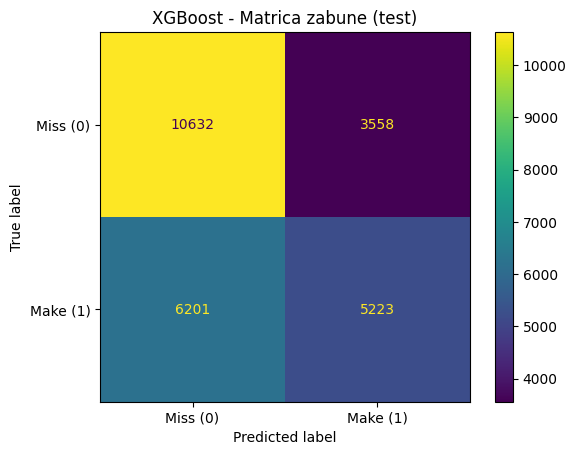

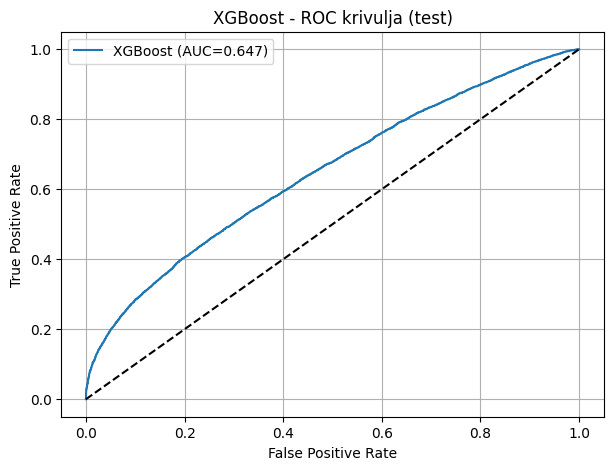

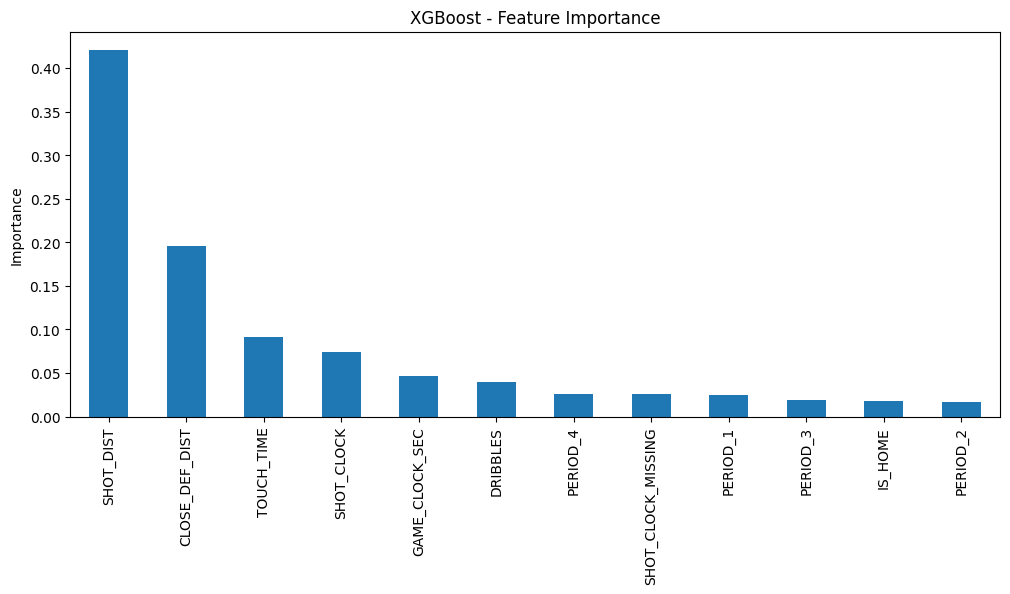

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)
from scipy.stats import randint, uniform, loguniform

features = [
    "SHOT_DIST", "CLOSE_DEF_DIST", "SHOT_CLOCK", "GAME_CLOCK_SEC",
    "SHOT_NUMBER", "DRIBBLES", "TOUCH_TIME",
    "PERIOD_1", "PERIOD_2", "PERIOD_3", "PERIOD_4", "PERIOD_5", "PERIOD_6", "PERIOD_7",
    "IS_HOME"
]

X = df_model_sorted[features]
y = df_model_sorted["FGM"]

X_train_xgb, X_validate_xgb, y_train_xgb, y_validate_xgb = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)

neg = (y_train_xgb == 0).sum()
pos = (y_train_xgb == 1).sum()
scale_pos_weight = float(neg) / float(pos) if pos > 0 else 1.0
print("scale_pos_weight:", scale_pos_weight)

xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=1,
    tree_method="hist",
    scale_pos_weight=scale_pos_weight
)

param_dist_xgb = {
    "n_estimators": randint(200, 900),
    "learning_rate": loguniform(0.02, 0.2),
    "max_depth": randint(3, 8),
    "min_child_weight": randint(1, 8),
    "subsample": uniform(0.7, 0.3),          # 0.7–1.0
    "colsample_bytree": uniform(0.7, 0.3),   # 0.7–1.0
    "reg_lambda": loguniform(1e-2, 10.0)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_xgb = RandomizedSearchCV(
    xgb,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search_xgb.fit(X_train_xgb, y_train_xgb)

print("Best params (XGB):", search_xgb.best_params_)
best_xgb = search_xgb.best_estimator_

y_val_pred = best_xgb.predict(X_validate_xgb)
y_val_prob = best_xgb.predict_proba(X_validate_xgb)[:, 1]

print("\nValidation accuracy:", accuracy_score(y_validate_xgb, y_val_pred))
print("Validation AUC:", roc_auc_score(y_validate_xgb, y_val_prob))
print("\nValidation report:\n", classification_report(y_validate_xgb, y_val_pred))

y_test_pred = best_xgb.predict(X_test)
y_test_prob = best_xgb.predict_proba(X_test)[:, 1]

print("\nTest accuracy:", accuracy_score(y_test, y_test_pred))
print("Test AUC:", roc_auc_score(y_test, y_test_prob))
print("\nTest report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Miss (0)", "Make (1)"]).plot(values_format="d")
plt.title("XGBoost - Matrica zabune (test)")
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_test_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC={roc_auc_score(y_test, y_test_prob):.3f})")
plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost - ROC krivulja (test)")
plt.legend()
plt.grid(True)
plt.show()

importances = best_xgb.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(12,5))
feat_imp.plot(kind="bar")
plt.title("XGBoost - Feature Importance")
plt.ylabel("Importance")
plt.show()


# 7. Zaključak

U radu je isprobano više klasifikacijskih pristupa za predviđanje uspješnosti NBA šuta, od jednostavnijih do složenijih modela. Logistička regresija i Naive Bayes poslužili su kao dobra početna linija, ali su pokazali ograničenu sposobnost analize složenih odnosa u podacima. SVM modeli, posebno s RBF kernelom, ostvarili su bolje rezultate, no uz veću računalnu složenost i potrebu za pažljivim podešavanjem hiperparametara. Neuronske mreže, Random Forest i Boosting pokazale su se najuspješnijima, pri čemu su Random Forest i Boosting modeli dali najbolji balans između točnosti i stabilnosti. Općenito, rezultati potvrđuju da složeniji i nelinearni pristupi bolje iskorištavaju dostupne značajke te daju pouzdanije predikcije ishoda šuta u odnosu na jednostavne linearne modele.